In [22]:
%reload_ext autoreload 
%autoreload 2 

# load functions
import functions

# imports
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack
from scipy.optimize import curve_fit
import matplotlib.lines as mlines
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import yaml

blue = "#4C78A8"
pink = "#F5859E"

import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.bottom": True,
    "xtick.top": True,
    "ytick.left": True,
    "ytick.right": True,
})

In [17]:
data = Table.read('data/radio_18ivc_data.csv')
data = data[np.argsort(data['phase'])]

# set global values for x and y axes of plots:
x_sed = (0.8*np.min(data['freq']), 1.2*np.max(data['freq']))
x_lc = (0.8*np.min(data['phase']), 1.2*np.max(data['phase']))
y_lims = (0.8*np.min(data['flux']), 1.2*np.max(data['flux']))

# Load in model independent parameters from config file
D, D_scale, nu_p_scale, F_p_scale, vel_conv = functions.load_model_indep_params("model_indep_params.yml")

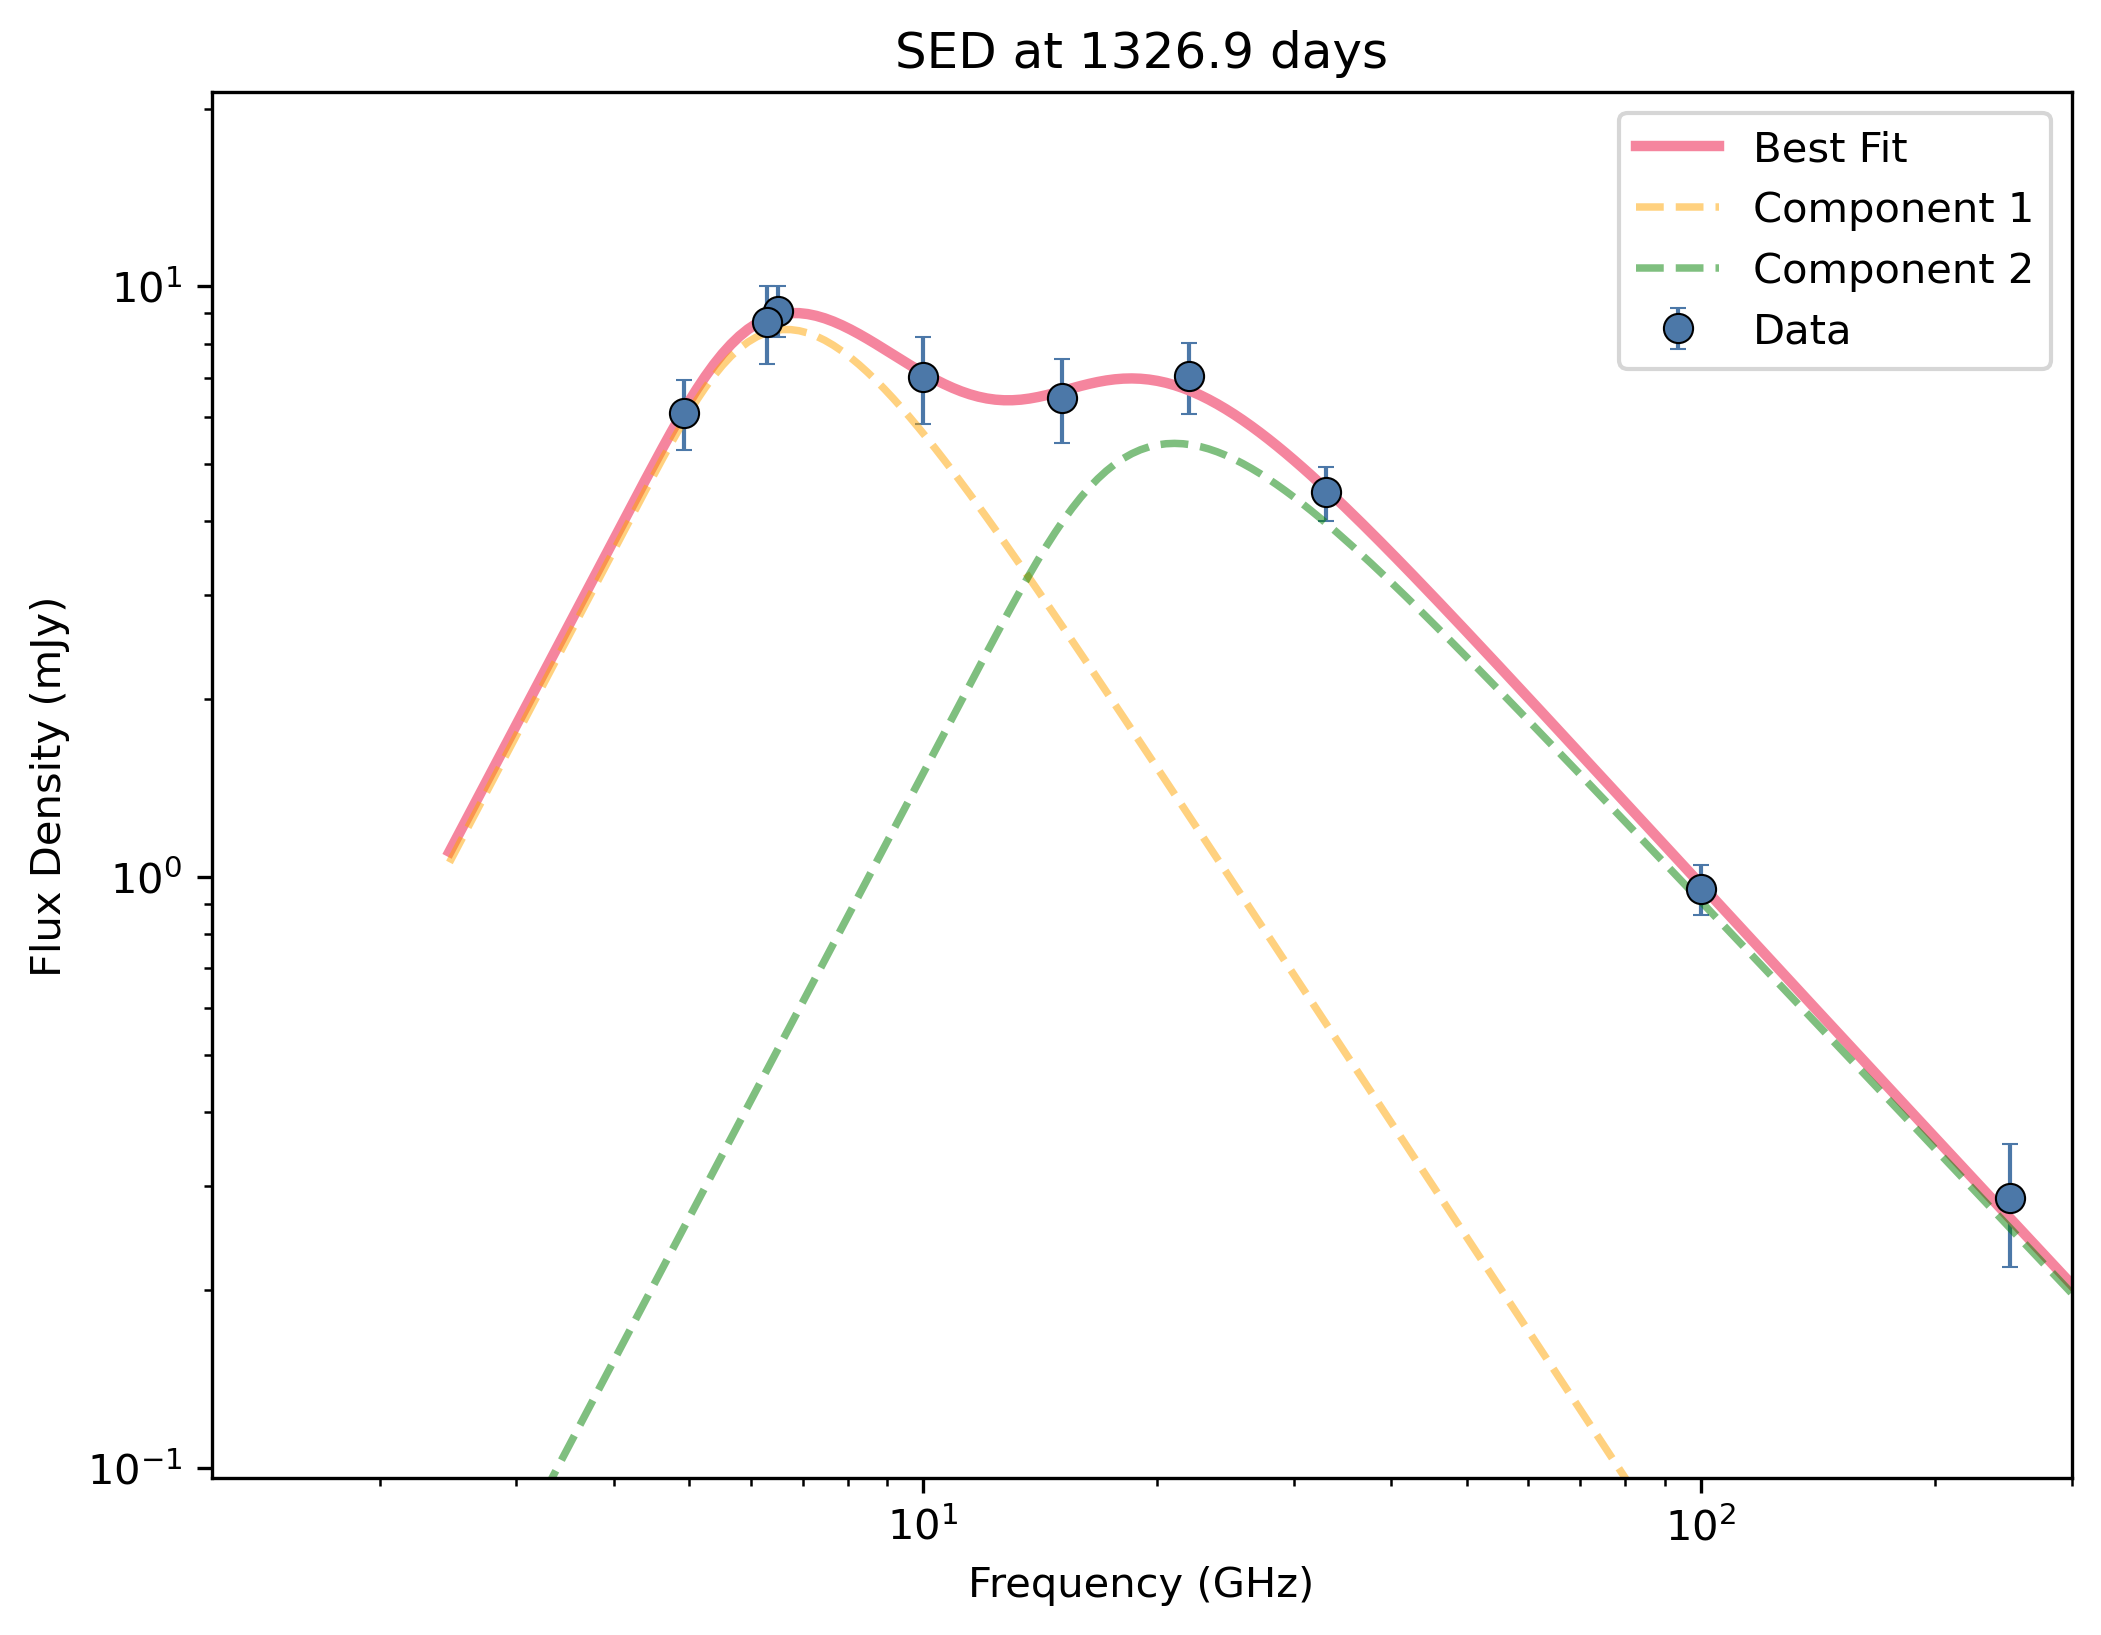

In [4]:
data = data[((data['phase']>=1200) & (data['phase']<=1400))]
avg_phase = np.mean(data['phase'])
# plot the data and the fit
fig, ax = plt.subplots(dpi=300, figsize=(8,6))
# plot data with error bars
freq = data['freq']
flux = data['flux']
ax.errorbar(freq, flux, yerr=data['flux_err'], fmt='o', ms=7, capsize=2, elinewidth=1, color=blue, 
            mec='black', mew=0.5,label='Data')
# plot best fit curve
freq_range = np.logspace(np.log10(min(freq)*0.5), np.log10(max(freq)*1.5), 200)
best_fit_params = [8.44397724245342,6.782679571348622,4.999999999999997, 5.390828461554526,20.05438971340149,3.783907567649094]
colors = ['orange', 'green', 'purple']
labels = ['Component 1', 'Component 2', 'Component 3']
# plot depending on how many components should be plotted
best_fit = functions.F_SSA_Nayana_2comp(freq_range, *best_fit_params)
ax.plot(freq_range, best_fit, color=pink, lw=2.5, label='Best Fit')
# plot component curves
comp1_curve = functions.F_SSA_Nayana(freq_range, best_fit_params[0], best_fit_params[1], best_fit_params[2])
comp2_curve = functions.F_SSA_Nayana(freq_range, best_fit_params[3], best_fit_params[4], best_fit_params[5])
ax.plot(freq_range, comp1_curve, label=labels[0], color=colors[0], linestyle='--', alpha=0.5, lw=1.8)
ax.plot(freq_range, comp2_curve, label=labels[1], color=colors[1], linestyle='--', alpha=0.5, lw=1.8)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(x_sed)
ax.set_ylim(y_lims)
ax.set_xlabel('Frequency (GHz)')
ax.set_ylabel('Flux Density (mJy)')
ax.set_title(f"SED at {avg_phase:.1f} days")
ax.legend() 

In [15]:
data[((data['phase']>=0.0) & (data['phase']<=5.0))]

phase,freq,flux,flux_err,telescope
float64,float64,float64,float64,str5


In [19]:
fit_4_1comp, chi2_4_1comp = functions.one_comp_ls_fit(data, 0.0, 5.0, x_sed[0], x_sed[1], [8.0, 180.0, 4.0], 
                                                      250.0, offset=0.0, amp_lower=3.0, chi2=True, plot=False)
fit_7_1comp, chi2_7_1comp = functions.one_comp_ls_fit(data, 5.0, 10.0, x_sed[0], x_sed[1], [8.0, 150.0, 4.0], 
                                                      151.28, offset=0.0, amp_lower=3.0, chi2=True, plot=False)
fit_17_1comp, chi2_17_1comp = functions.one_comp_ls_fit(data, 10.0, 20.0, x_sed[0], x_sed[1], [15.0, 80.0, 4.0], 
                                                      127.72, offset=0.0, amp_lower=3.0, chi2=True, plot=False)
fit_200_1comp, chi2_200_1comp = functions.one_comp_ls_fit(data, 180.0, 300.0, x_sed[0], x_sed[1], [6.0, 70.0, 4.0], 
                                                      77.95, offset=0.0, amp_lower=0.1, chi2=True, plot=False)
fit_1300_2comp, chi2_1300_2comp = functions.two_comp_ls_fit(data, 1200, 1400, x_sed[0], x_sed[1], [8.0, 7.0, 3.85], 
                                                            [6.0, 23.0, 3.85], 77.95, 77.95, offset=0.0, amp_lower=3.0, 
                                                            chi2=True, plot=False)

Single component best fit parameters: [  7.5753798  151.28501017   4.95732811]
Chi-squared: 0.00, Reduced Chi-squared: -0.00
Single component best fit parameters: [  9.18443952 127.72299139   4.52755427]
Chi-squared: 0.00, Reduced Chi-squared: -0.00
Single component best fit parameters: [10.13605264 77.95935895  4.18942338]
Chi-squared: 0.00, Reduced Chi-squared: -0.00
Single component best fit parameters: [ 0.47088919 12.05000002  2.        ]
Chi-squared: 27.12, Reduced Chi-squared: 9.04
Two component best fit parameters: [ 8.44398198  6.78268186  5.          5.39082689 20.05441941  3.78391014]
Chi-squared: 0.39, Reduced Chi-squared: 0.13


Text(0.1, 0.94, '1300 days')

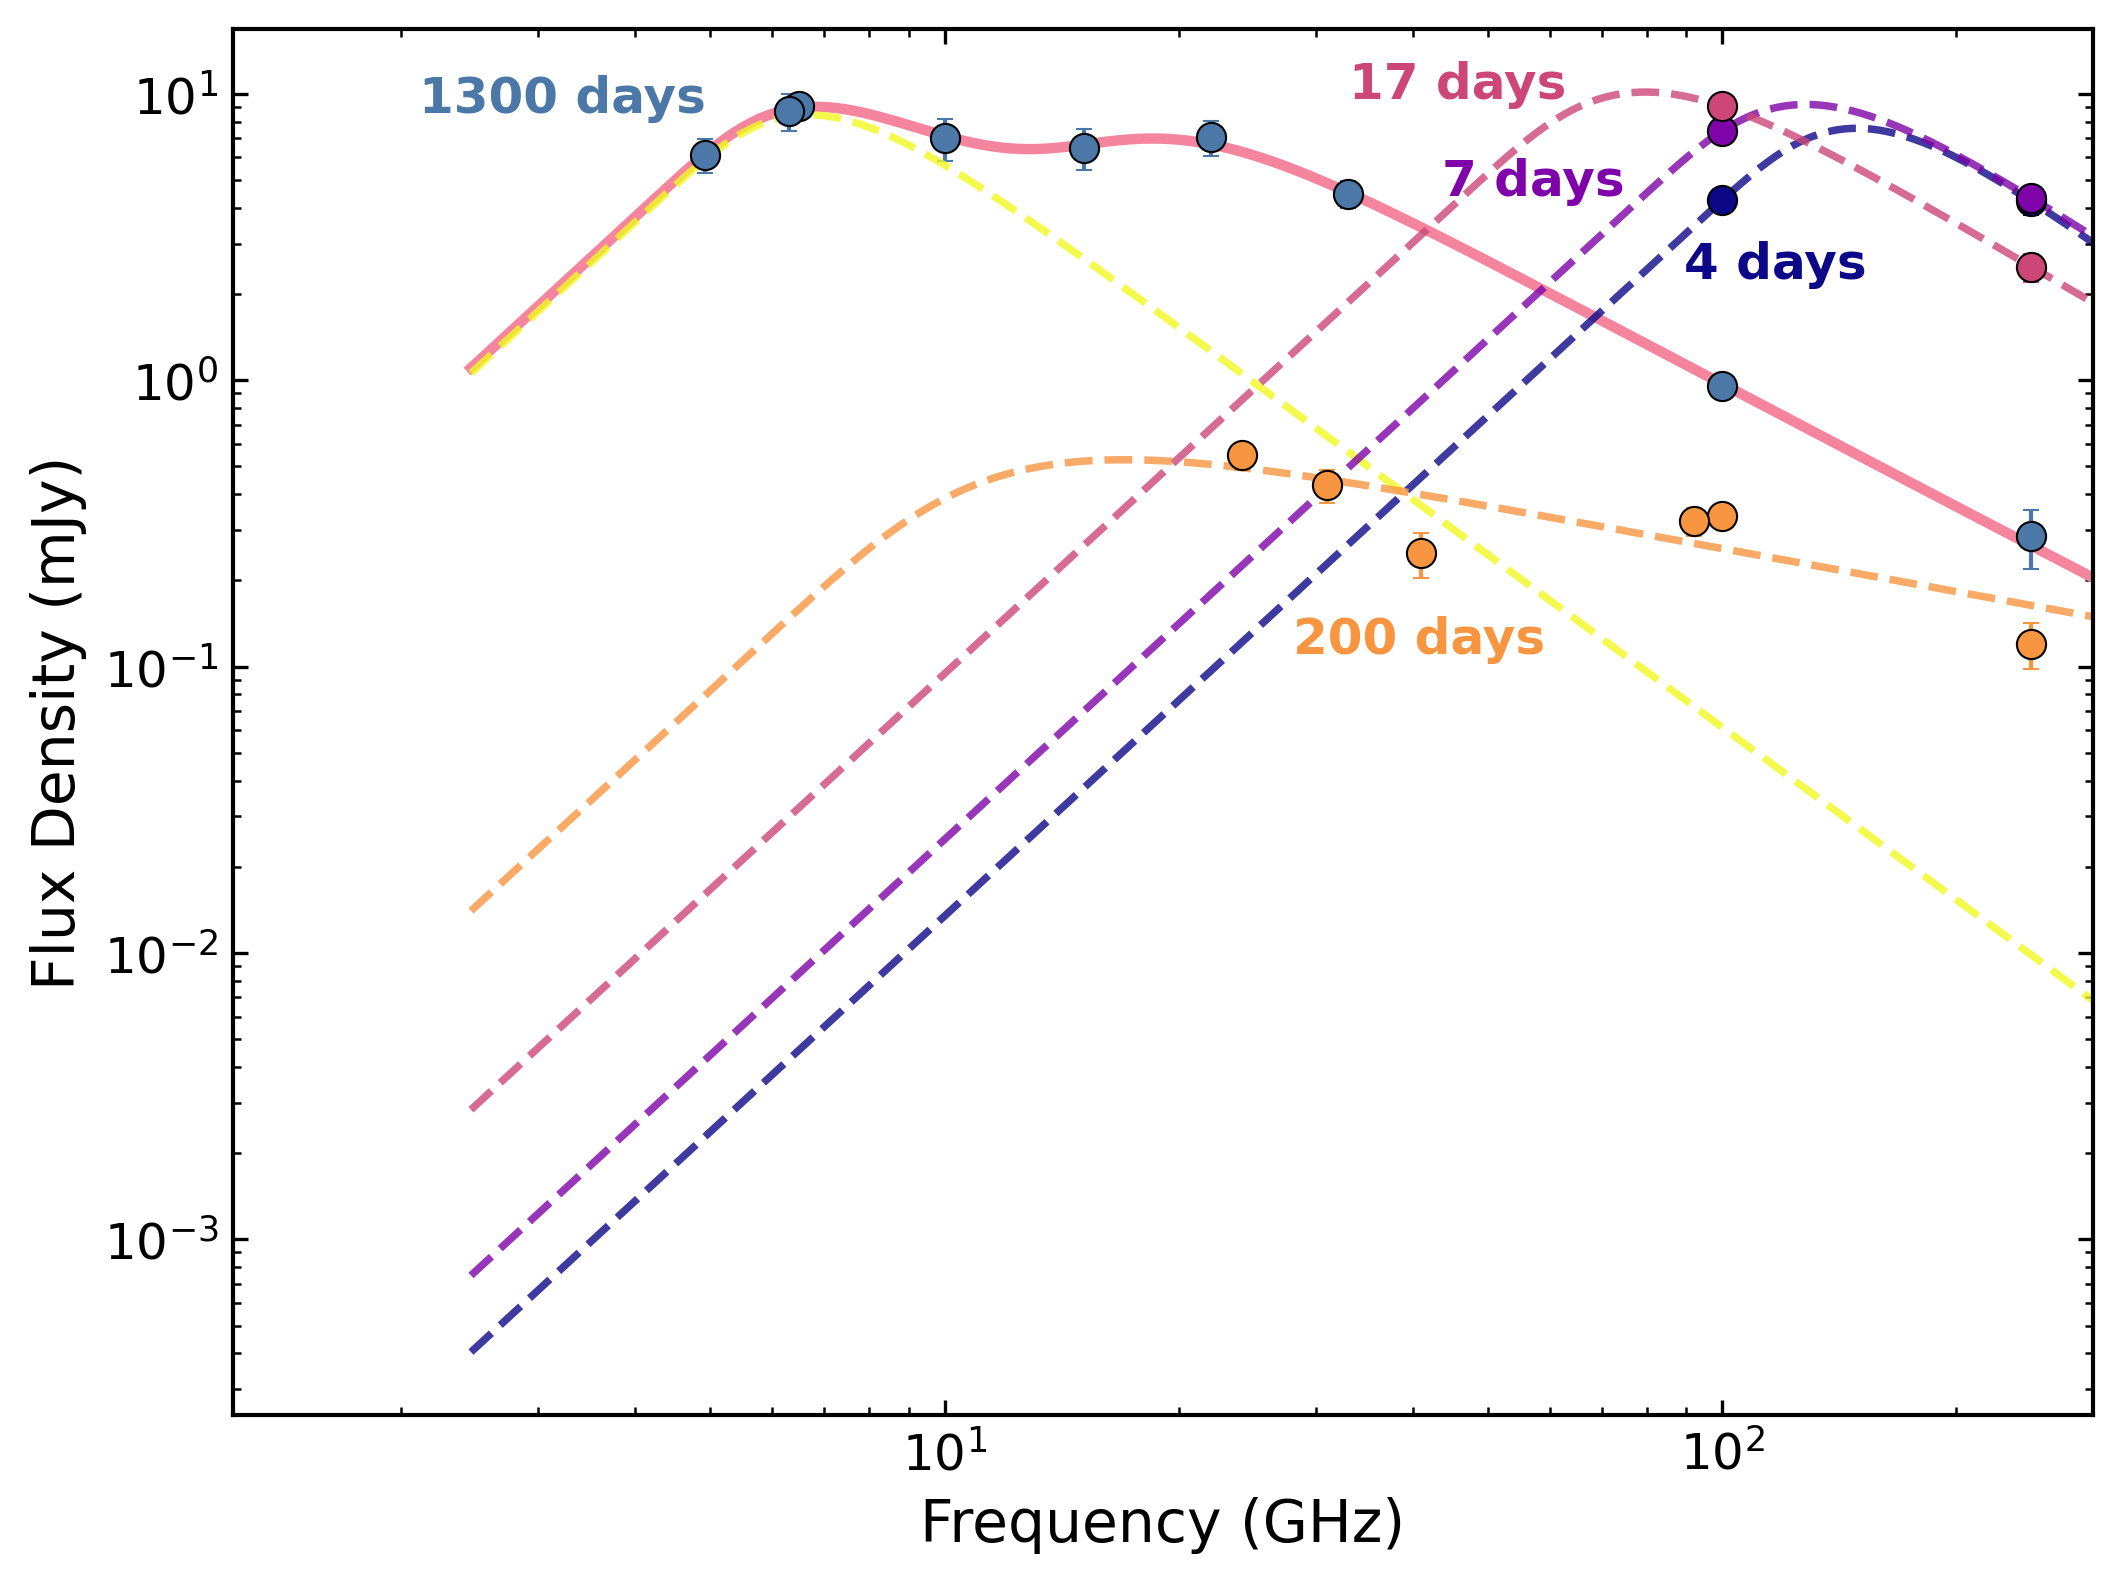

In [29]:
color_fits = [
    "#0d0887",  # deep purple
    "#7e03a8",  # purple
    "#cc4778",  # pink
    "#f89540",  # orange
    "#f0f921",  # yellow
]

data_epoch = data[((data['phase']>=1200) & (data['phase']<=1400))]
avg_phase = np.mean(data_epoch['phase'])
# plot the data and the fit
fig, ax = plt.subplots(dpi=300, figsize=(8,6))
# plot data with error bars
freq = data_epoch['freq']
flux = data_epoch['flux']

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(x_sed)
#ax.set_ylim(y_lims)
ax.set_xlabel('Frequency (GHz)')
ax.set_ylabel('Flux Density (mJy)')
#ax.set_title(f"SED at {avg_phase:.1f} days")
#ax.legend() 

ax.errorbar(freq, flux, yerr=data_epoch['flux_err'], fmt='o', ms=7, capsize=2, elinewidth=1, color=blue, 
            mec='black', mew=0.5,label='Data')
# plot best fit curve
freq_range = np.logspace(np.log10(min(freq)*0.5), np.log10(max(freq)*1.5), 200)
best_fit_params = [8.44397724245342,6.782679571348622,4.999999999999997, 5.390828461554526,20.05438971340149,3.783907567649094]
colors = ['orange', 'green', 'purple']
labels = ['Component 1', 'Component 2', 'Component 3']
# plot depending on how many components should be plotted
best_fit = functions.F_SSA_Nayana_2comp(freq_range, *best_fit_params)
ax.plot(freq_range, best_fit, color=pink, lw=2.5, label='Best Fit')
# plot component curves
comp1_curve = functions.F_SSA_Nayana(freq_range, best_fit_params[0], best_fit_params[1], best_fit_params[2])
comp2_curve = functions.F_SSA_Nayana(freq_range, best_fit_params[3], best_fit_params[4], best_fit_params[5])
ax.plot(freq_range, comp1_curve, label=labels[0], color=color_fits[-1], linestyle='--', alpha=0.8, lw=1.8)
#ax.plot(freq_range, comp2_curve, label=labels[1], color=colors[1], linestyle='--', alpha=0.8, lw=1.8)



y_positions = [0.82, 0.88, 0.95, 0.55, 0.94]

data_4 = data[((data['phase']>=0) & (data['phase']<=5))]
ax.errorbar(data_4['freq'], data_4['flux'], yerr=data_4['flux_err'], fmt='o', ms=7, capsize=2, elinewidth=1, color=color_fits[0], 
            mec='black', mew=0.5,label='Data')
day4_curve = functions.F_SSA_Nayana(freq_range, 7.5753798,  151.28501017,   4.95732811)
ax.plot(freq_range, day4_curve, label=labels[0], color=color_fits[0], linestyle='--', alpha=0.8, lw=1.8)
ax.text(0.78, y_positions[0], "4 days",
        transform=ax.transAxes,
        color=color_fits[0], fontsize=12, weight='bold')

data_7 = data[((data['phase']>=5) & (data['phase']<=10))]
ax.errorbar(data_7['freq'], data_7['flux'], yerr=data_7['flux_err'], fmt='o', ms=7, capsize=2, elinewidth=1, color=color_fits[1], 
            mec='black', mew=0.5,label='Data')
day7_curve = functions.F_SSA_Nayana(freq_range,   9.18443952, 127.72299139,   4.52755427)
ax.plot(freq_range, day7_curve, label=labels[0], color=color_fits[1], linestyle='--', alpha=0.8, lw=1.8)
ax.text(0.65, y_positions[1], "7 days",
        transform=ax.transAxes,
        color=color_fits[1], fontsize=12, weight='bold')

data_17 = data[((data['phase']>=10) & (data['phase']<=20))]
ax.errorbar(data_17['freq'], data_17['flux'], yerr=data_17['flux_err'], fmt='o', ms=7, capsize=2, elinewidth=1, color=color_fits[2], 
            mec='black', mew=0.5,label='Data')
day17_curve = functions.F_SSA_Nayana(freq_range,10.13605264, 77.95935895,  4.18942338)
ax.plot(freq_range, day17_curve, label=labels[0], color=color_fits[2], linestyle='--', alpha=0.8, lw=1.8)
ax.text(0.6, y_positions[2], "17 days",
        transform=ax.transAxes,
        color=color_fits[2], fontsize=12, weight='bold')

data_200 = data[((data['phase']>=180) & (data['phase']<=300))]
ax.errorbar(data_200['freq'], data_200['flux'], yerr=data_200['flux_err'], fmt='o', ms=7, capsize=2, elinewidth=1, color=color_fits[3], 
            mec='black', mew=0.5,label='Data')
day200_curve = functions.F_SSA_Nayana(freq_range, 0.47088919, 12.05000002,  2.0)
ax.plot(freq_range, day200_curve, label=labels[0], color=color_fits[3], linestyle='--', alpha=0.8, lw=1.8)
ax.text(0.57, y_positions[3], "200 days",
        transform=ax.transAxes,
        color=color_fits[3], fontsize=12, weight='bold')

ax.text(0.1, y_positions[4], "1300 days",
        transform=ax.transAxes,
        color=blue, fontsize=12, weight='bold')